In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/satyasaibodireddy/dataset-for-data-analytics-1/Dataset for Data Analytics (1).xlsx


Shape: (1200, 14)

Columns:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']

Data types:
OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object

Missing values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0

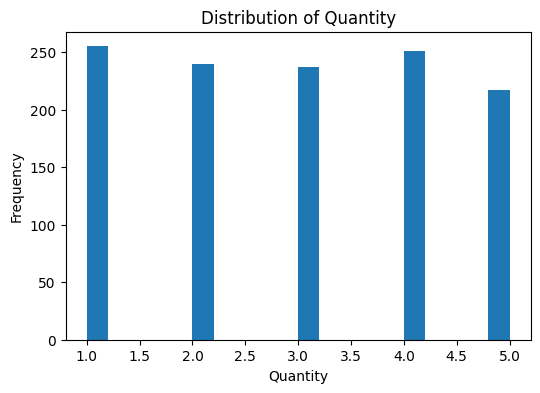

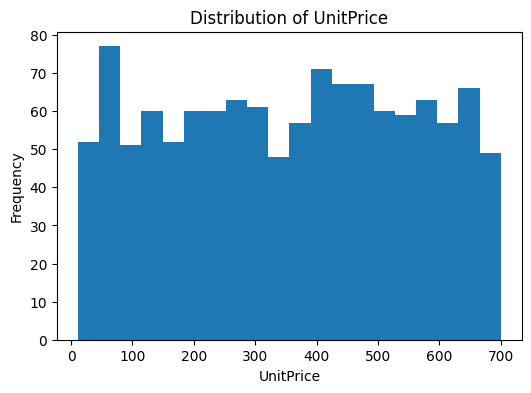

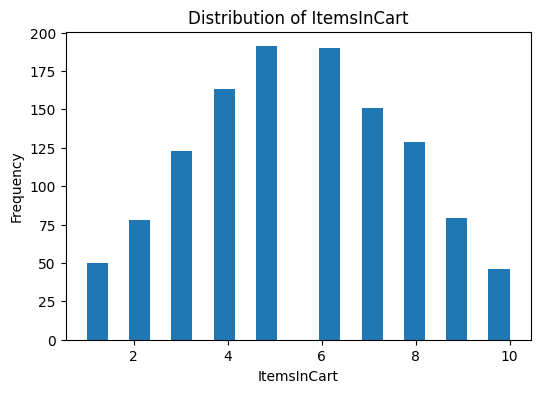

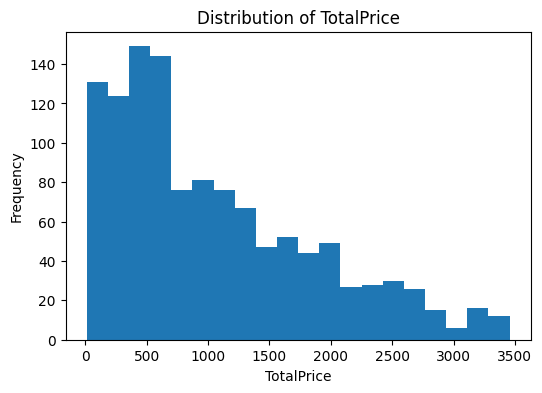

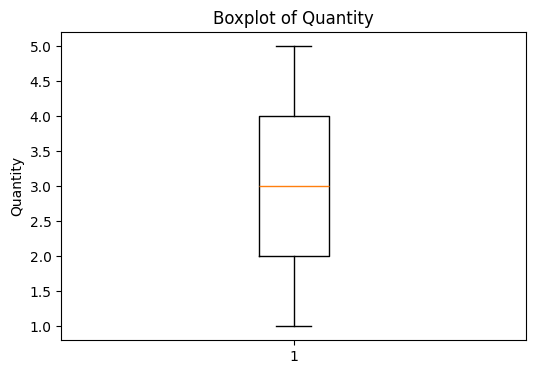

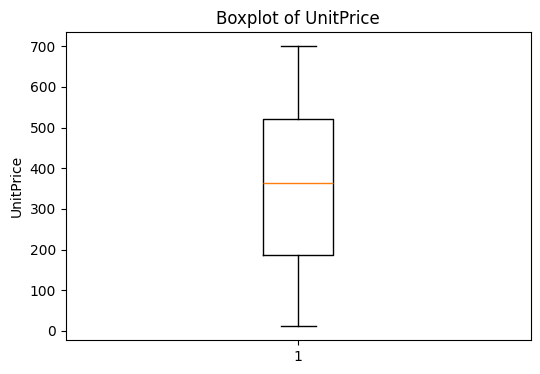

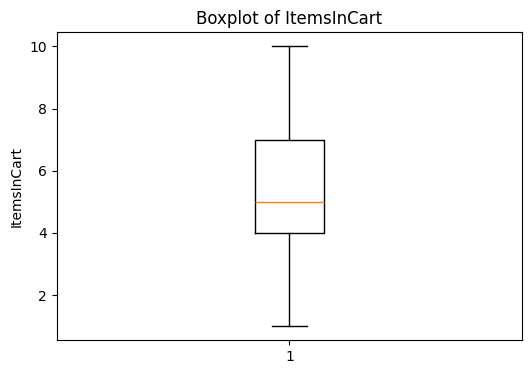

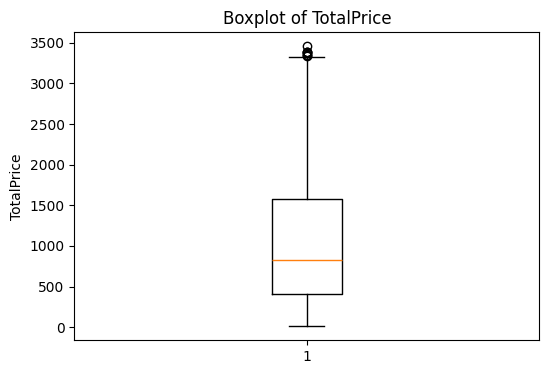


Outlier count by column (IQR method):
Quantity: 0
UnitPrice: 0
ItemsInCart: 0
TotalPrice: 8

Correlation matrix:
             Quantity  UnitPrice  ItemsInCart  TotalPrice
Quantity     1.000000   0.014553     0.650061    0.615251
UnitPrice    0.014553   1.000000     0.000602    0.717081
ItemsInCart  0.650061   0.000602     1.000000    0.392540
TotalPrice   0.615251   0.717081     0.392540    1.000000


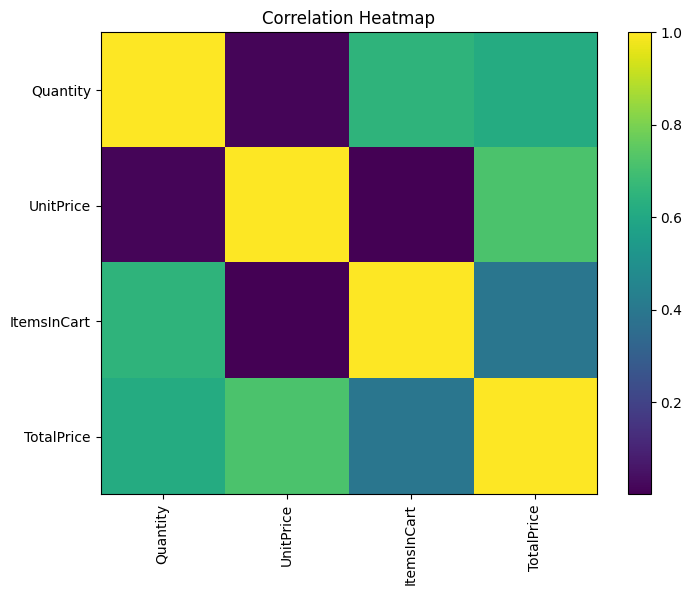

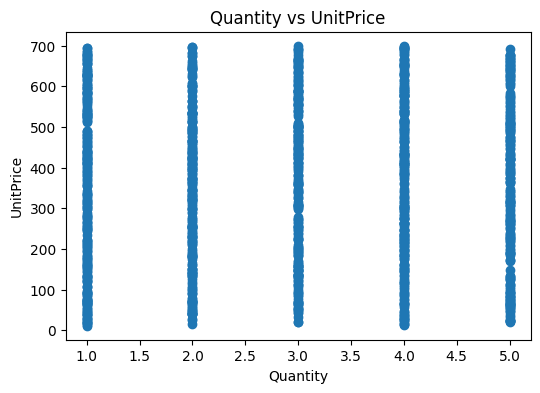

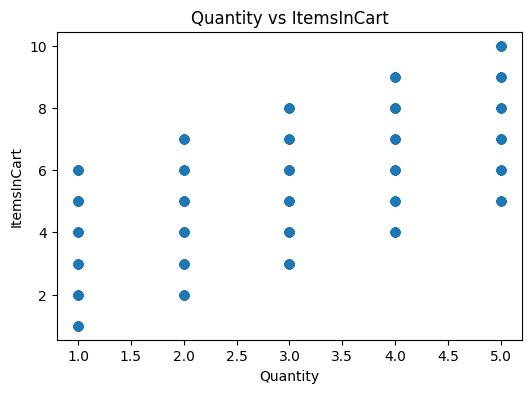

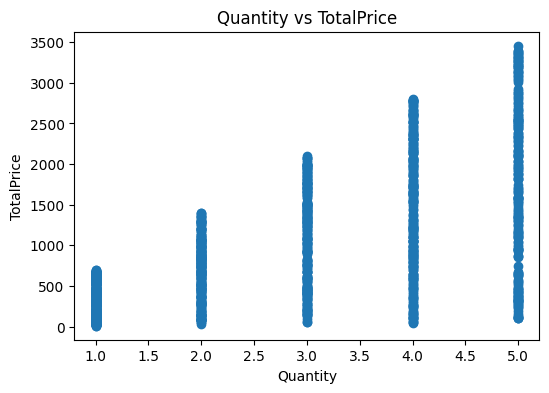

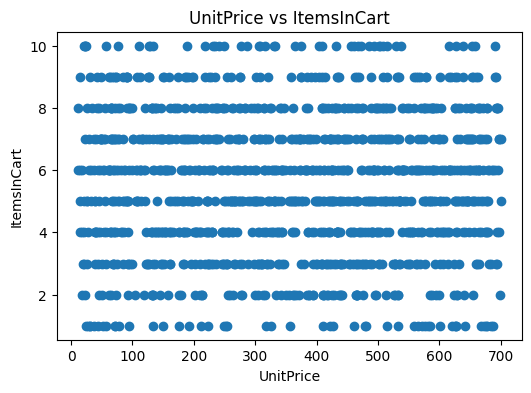

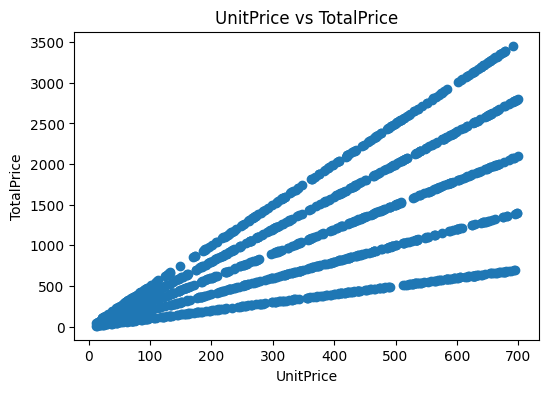

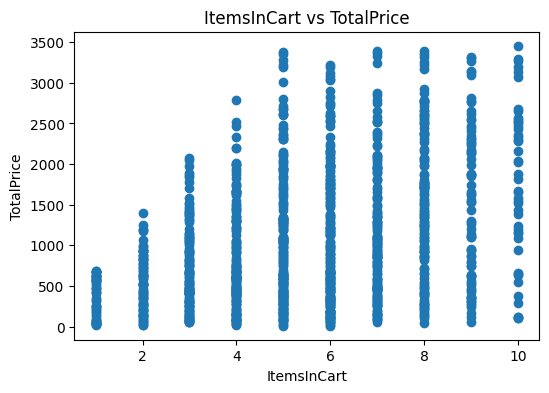


Skewness of numeric columns:
Quantity       0.027922
UnitPrice     -0.026512
ItemsInCart    0.000877
TotalPrice     0.891359
dtype: float64

EDA Completed Successfully.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
file_path = "/kaggle/input/datasets/satyasaibodireddy/dataset-for-data-analytics-1/Dataset for Data Analytics (1).xlsx"
df = pd.read_excel(file_path)
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nFirst 5 rows:")
print(df.head())
print("\nDescriptive statistics:")
print(df.describe(include='all'))
numeric_df = df.select_dtypes(include=np.number)
print("\nNumeric columns:")
print(numeric_df.columns.tolist())
print("\nMean:")
print(numeric_df.mean())
print("\nMedian:")
print(numeric_df.median())
print("\nCount:")
print(numeric_df.count())
for col in numeric_df.columns:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()
for col in numeric_df.columns:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()
outlier_summary = {}
for col in numeric_df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = len(outliers)
print("\nOutlier count by column (IQR method):")
for col, count in outlier_summary.items():
    print(f"{col}: {count}")
corr = numeric_df.corr()
print("\nCorrelation matrix:")
print(corr)
plt.figure(figsize=(8,6))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()
cols = numeric_df.columns.tolist()

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        plt.figure(figsize=(6,4))
        plt.scatter(df[cols[i]], df[cols[j]])
        plt.xlabel(cols[i])
        plt.ylabel(cols[j])
        plt.title(f"{cols[i]} vs {cols[j]}")
        plt.show()
print("\nSkewness of numeric columns:")
print(numeric_df.skew())
print("\nEDA Completed Successfully.")